# Week 4 Task: Ensemble Methods (Random Forest, XGBoost) vs Baseline Model

## Objective
Train two ensemble models (**Random Forest** and **XGBoost**) and compare their performance with a **baseline model** on the same dataset.

## What this notebook covers
- Load a real dataset
- Basic data quality checks
- Train/Test split (with stratification)
- Baseline model training
- Random Forest training
- XGBoost training
- Evaluation and comparison (Accuracy, F1, ROC-AUC)
- Simple feature importance review

> Dataset used: **Breast Cancer Wisconsin** (built into scikit-learn).  
> Why: clean, real-world, binary classification, good for comparing models.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt

## Install XGBoost (Colab usually needs this)
We use XGBoost as a strong ensemble learner (gradient boosting).

In [ ]:
!pip -q install xgboost
from xgboost import XGBClassifier

## 1) Load dataset
Target:
- `0` = malignant
- `1` = benign

We will build a dataframe for easier inspection and quality checks.

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (569, 30)
y shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2) Data Quality Checks (fundamentals)
We check:
- Missing values
- Duplicates
- Basic stats
- Class balance (to avoid misleading accuracy)

In [ ]:
# Missing values
missing = X.isna().sum().sort_values(ascending=False)
print("Top missing values (should be 0):")
print(missing.head(10))

# Duplicate rows
dup_count = X.duplicated().sum()
print("\nDuplicate rows in X:", dup_count)

# Basic statistics
display(X.describe().T.head(10))

# Class balance
class_counts = y.value_counts()
print("\nClass distribution:")
print(class_counts)
print("\nClass proportions:")
print((class_counts / len(y)).round(3))

Top missing values (should be 0):
mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64

Duplicate rows in X: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744



Class distribution:
target
1    357
0    212
Name: count, dtype: int64

Class proportions:
target
1    0.627
0    0.373
Name: count, dtype: float64


## 3) Train/Test Split
We use **stratified split** so class ratios remain similar in train and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (455, 30)  Test size: (114, 30)


## 4) Evaluation helper
We compute:
- Accuracy
- F1-score
- ROC-AUC (uses predicted probabilities)
Also prints confusion matrix + classification report.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    # Some models support predict_proba; needed for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print("Accuracy:", round(acc, 4))
    print("F1-score:", round(f1, 4))
    print("ROC-AUC:", round(auc, 4))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    return {"Model": model_name, "Accuracy": acc, "F1": f1, "ROC_AUC": auc}

## 5) Baseline Model: Logistic Regression
Why this is a baseline:
- Simple
- Fast
- Works well on many linear problems
- Often used as a reference point

We scale features using `StandardScaler` because logistic regression performs better with standardized inputs.

In [ ]:
baseline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

baseline.fit(X_train, y_train)
baseline_results = evaluate_model(baseline, X_test, y_test, "Baseline: Logistic Regression")


=== Baseline: Logistic Regression ===
Accuracy: 0.9825
F1-score: 0.9861
ROC-AUC: 0.9954

Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 6) Ensemble Model 1: Random Forest
Random Forest is an ensemble of decision trees.
Key idea:
- Many trees trained on bootstrapped samples
- Random subset of features at each split
- Reduces variance (less overfitting than a single tree)

No scaling is required for tree-based models.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_results = evaluate_model(rf, X_test, y_test, "Ensemble: Random Forest")


=== Ensemble: Random Forest ===
Accuracy: 0.9474
F1-score: 0.9583
ROC-AUC: 0.9937

Confusion Matrix:
 [[39  3]
 [ 3 69]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## 7) Ensemble Model 2: XGBoost (Gradient Boosting)
XGBoost builds trees sequentially.
Each new tree tries to fix errors made by previous trees.

Why it’s powerful:
- Strong performance on structured/tabular data
- Regularization options to reduce overfitting
- Handles complex patterns better than linear models

We set:
- `eval_metric="logloss"` for binary classification
- `n_estimators`, `learning_rate`, `max_depth` as core parameters

In [ ]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_results = evaluate_model(xgb, X_test, y_test, "Ensemble: XGBoost")


=== Ensemble: XGBoost ===
Accuracy: 0.9561
F1-score: 0.966
ROC-AUC: 0.995

Confusion Matrix:
 [[38  4]
 [ 1 71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 8) Compare performance (Test set)
We put all results into a table and rank by ROC-AUC (strong metric for binary classification).

In [ ]:
results_df = pd.DataFrame([baseline_results, rf_results, xgb_results])
results_df = results_df.sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,F1,ROC_AUC
0,Baseline: Logistic Regression,0.982456,0.986111,0.995370
1,Ensemble: XGBoost,0.956140,0.965986,0.995040
2,Ensemble: Random Forest,0.947368,0.958333,0.993717


## 9) Stronger comparison: Cross-validation (CV)
A single train/test split can be lucky or unlucky.

So we also run **Stratified K-Fold CV** and compare average metrics:
- Accuracy
- F1
- ROC-AUC

This gives a more reliable comparison.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "Baseline: Logistic Regression": baseline,
    "Ensemble: Random Forest": rf,
    "Ensemble: XGBoost": xgb
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "CV Accuracy (mean)": scores["test_accuracy"].mean(),
        "CV F1 (mean)": scores["test_f1"].mean(),
        "CV ROC-AUC (mean)": scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(cv_rows).sort_values(by="CV ROC-AUC (mean)", ascending=False).reset_index(drop=True)
cv_df

,Model,CV Accuracy (mean),CV F1 (mean),CV ROC-AUC (mean)
0,Baseline: Logistic Regression,0.973669,0.979434,0.995314
1,Ensemble: XGBoost,0.959571,0.967955,0.994111
2,Ensemble: Random Forest,0.952569,0.962421,0.989477


## 10) Feature Importance (Interpretability)
Ensembles can show which features matter most.

- Random Forest: `feature_importances_`
- XGBoost: `feature_importances_`

This helps interpret the model, even if it is not perfect explanation.

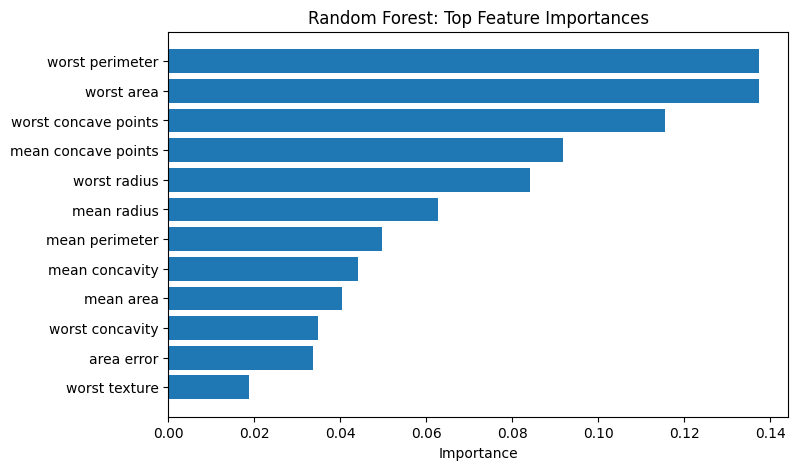

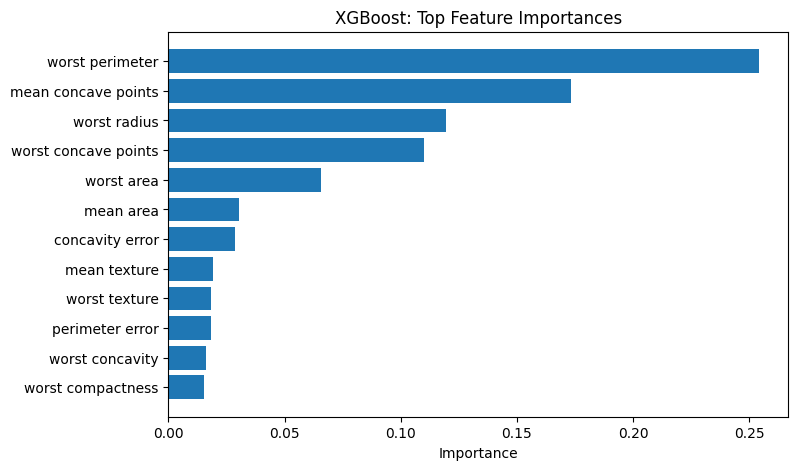

In [ ]:
def plot_top_features(importances, feature_names, title, top_n=12):
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 5))
    plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
    plt.title(title)
    plt.xlabel("Importance")
    plt.show()

plot_top_features(rf.feature_importances_, X.columns, "Random Forest: Top Feature Importances")
plot_top_features(xgb.feature_importances_, X.columns, "XGBoost: Top Feature Importances")